## essential libraries


In [110]:
import tensorflow as tf
from tensorflow. keras import models, layers 
import matplotlib.pyplot as plt
import numpy as np


In [52]:
IMAGE_SIZE = 256
BATCH_SİZE = 32
CHANELLS = 3
EPOCHS = 50 #as mouch as epochs our model will perform better but it will take more time to train the model

In [53]:
dataset =tf.keras.preprocessing.image_dataset_from_directory(
    "training" ,
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SİZE
)   

Found 2152 files belonging to 3 classes.


In [54]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [55]:
len(dataset) ## cuz we have 68 batches of data

68

In [56]:
68*32 ## 2176 images in total

2176

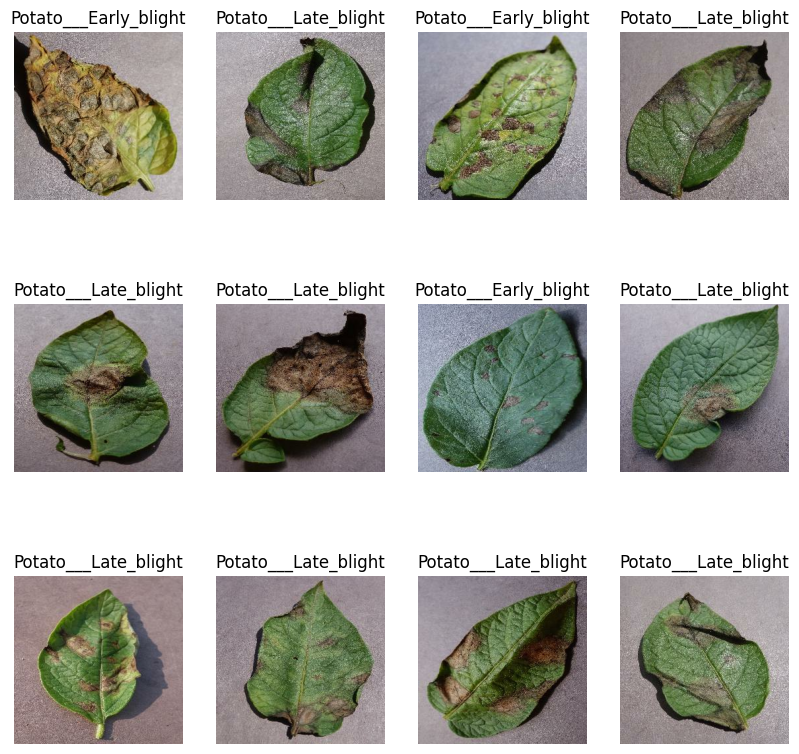

In [57]:
plt.figure(figsize=(10,10))

for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")



# we will use the following values 
80% training
 10% validation 
 10%test

In [58]:
len(dataset)
train_size = 0.8
len(dataset)*train_size 
train_ds = dataset.take(54)
len(train_ds)
remaining = dataset.skip(54)
len(remaining)
##this is the remaining 20% of the data for testing
val_size = 0.1
len(dataset)*val_size
val_ds = remaining.take(6)
len(val_ds)
test_ds = remaining.skip(6)
len(test_ds)

8

or we can just write a wel organized function for all above operations

In [59]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True,shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)


    return train_ds, val_ds, test_ds


In [60]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

we can boost the model by applying cache and prefetch methods (https://www.tensorflow.org/guide/data_performance)

In [61]:
train_ds = train_ds.cache().shuffle (1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

if we feed our model with external deta we need to rescale it as below:

In [62]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),  # Resize images to (Image_Size, Image_Size)
    layers.Rescaling(1.0/255)  # Rescale pixel values from [0, 255] to [0, 1]
])

also we can apply a data augmentation layer to boost the model with extra data

In [63]:
data_augmentation = tf.keras.Sequential([
layers.RandomFlip("horizontal_and_vertical"), 
layers.RandomRotation (0.2),
])

## Building the model

In [64]:
input_shape = (BATCH_SİZE,IMAGE_SIZE, IMAGE_SIZE,CHANELLS)
n_classes = 3


model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3), activation="relu", input_shape= input_shape),# i gave 32 layers because it must be a power of 2 to optimize the gpu
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),#to convert the 2D feature maps into a 1D feature vector that can be fed into the fully connected layers
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax"),# to convert the output to a probability distribution over the classes


])
model.build(input_shape= input_shape)

/Users/ismail/mlProject/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(#this is for the training process
optimizer= 'adam',
loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
metrics=['accuracy' ]
)

In [67]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SİZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 653ms/step - accuracy: 0.4531 - loss: 0.9219 - val_accuracy: 0.4167 - val_loss: 0.9230
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 669ms/step - accuracy: 0.5272 - loss: 0.8647 - val_accuracy: 0.7552 - val_loss: 0.7217
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 721ms/step - accuracy: 0.6562 - loss: 0.7220 - val_accuracy: 0.7552 - val_loss: 0.6474
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 755ms/step - accuracy: 0.7755 - loss: 0.5093 - val_accuracy: 0.8073 - val_loss: 0.4454
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 763ms/step - accuracy: 0.8125 - loss: 0.4402 - val_accuracy: 0.8229 - val_loss: 0.4876
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 776ms/step - accuracy: 0.8686 - loss: 0.3400 - val_accuracy: 0.8385 - val_loss: 0.3504
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 790ms/step - accuracy: 0.8438 - loss: 0.3518 - val_accuracy: 0.8542 - val_loss: 0.3317
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 787ms/step - accuracy: 0.8796 - loss: 0.2695 - val_accu

In [68]:
scores= model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 365ms/step - accuracy: 0.9805 - loss: 0.0473


In [69]:
history #(https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/History) for more details about the history object

In [70]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [71]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Performance Of The Model

In [72]:
acc = history. history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Accuracy')

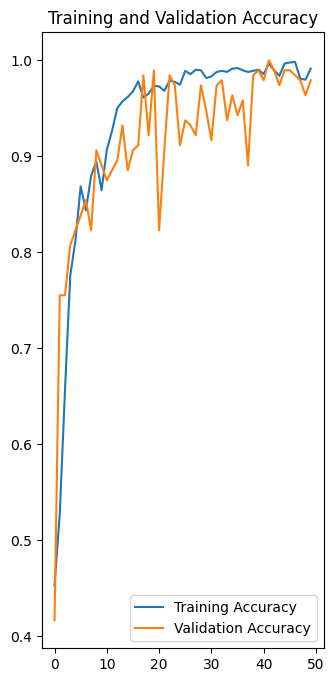

In [73]:

plt. figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt. plot(range(EPOCHS),val_acc, label='Validation Accuracy')
plt. legend(loc='lower right')
plt. title( 'Training and Validation Accuracy')

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step
              precision    recall  f1-score   support

           0       0.53      0.53      0.53        80
           1       0.55      0.53      0.54        98
           2       0.22      0.29      0.25        14

    accuracy                           0.51       192
   macro avg       0.43      0.45      0.44       192
weighted avg       0.52      0.51      0.51       192

Precision: 0.5173118597320725
Recall: 0.5104166666666666


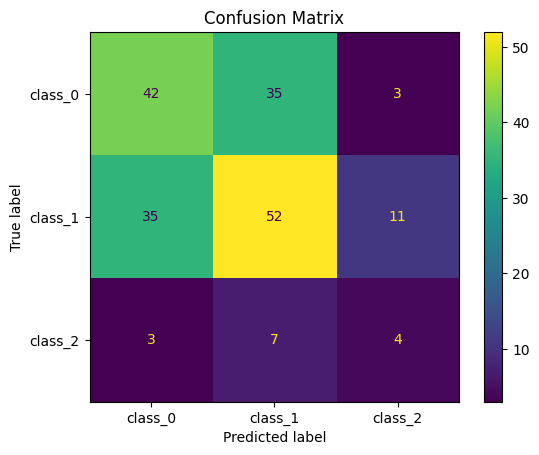

In [74]:
import numpy as np
from sklearn.metrics import classification_report, precision_score, recall_score,ConfusionMatrixDisplay, confusion_matrix

# Get predictions
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels from dataset
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Full report
print(classification_report(y_true, y_pred))

# Individual scores
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['class_0', 'class_1', 'class_2']).plot()
plt.title('Confusion Matrix')
plt.show()

Testing the model 

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
predicted label:  Potato___Late_blight


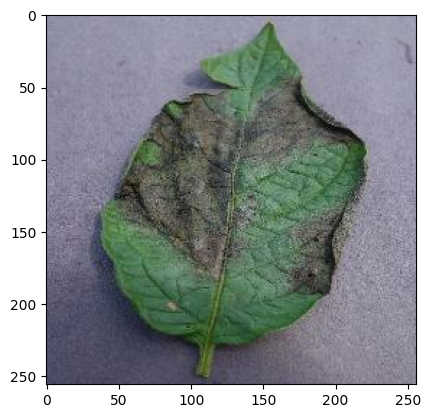

In [129]:
for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    print("first image to predict")
    plt. imshow(first_image)
    print("actual label:",class_names[first_label])
    batch_prediction = model. predict(images_batch)
    print("predicted label: ",class_names[np.argmax(batch_prediction[0])])



# wrong samples

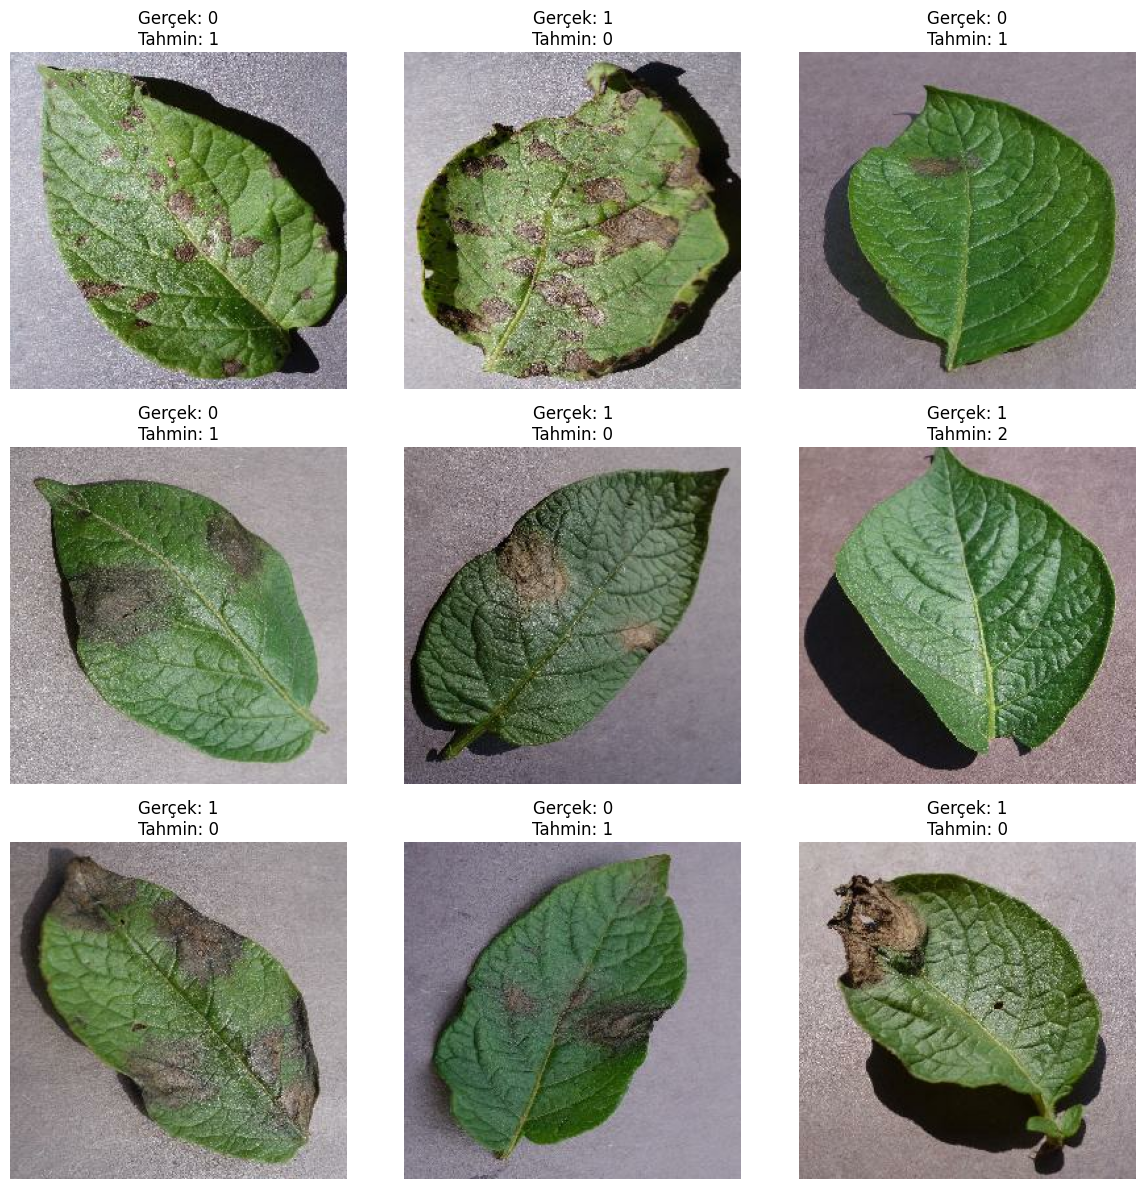

In [134]:
wrong_indices = np.where(y_true != y_pred)[0]# the reason of the [0] because we return index instead of tuple

# İlk 9 hatalı örneği göster
plt.figure(figsize=(12, 12))
for i, idx in enumerate(wrong_indices[:9]):
    image, label = list(val_ds.unbatch())[idx]
    plt.subplot(3, 3, i+1)
    plt.imshow(image.numpy().astype('uint8'))
    plt.title(f"Gerçek: {y_true[idx]}\nTahmin: {y_pred[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()